In [1]:
from libraries import *

/home/mehdi/rl-env/bin/python3


In [2]:
gp.setParam("OutputFlag", 0)

Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-16


      Time_s  Longitude_deg  Latitude_deg   Altitude_m
0        0.0     279.000000     49.000000  25000.00000
1     1800.0     278.991146     49.029046  23678.70919
4     3600.0     278.974006     49.042329  23672.57558
7     5400.0     278.954818     49.050965  23307.62729
10    7200.0     278.932833     49.055108  22986.64633
13    9000.0     278.880577     49.044621  20913.29464
16   10800.0     278.900893     49.018890  19378.08451
19   12600.0     278.949781     48.997741  19373.21189
22   14400.0     278.989935     48.980466  20387.52864
25   16200.0     279.004618     48.984263  21367.19138
28   18000.0     279.006678     48.992932  21378.46182
31   19800.0     279.022780     49.000290  21723.81151
34   21600.0     279.038680     49.008456  21722.88519
37   23400.0     279.059257     49.017817  23222.08889
40   25200.0     279.061682     49.024487  23068.06755
43   27000.0     279.064344     49.029620  22978.23955
46   28800.0     279.067620     49.034208  22980.28988
49   30600

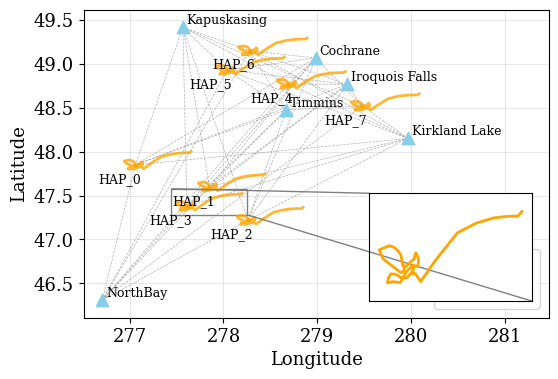

⏱️ Calculating K_MAX from t=0 to t=47 (48 time steps)
[INFO] Loaded checkpoint from K_MAX_checkpoint.pkl
✅ Requested interval [0, 48) fully covered in checkpoint.


/home/mehdi/Downloads/Backup/HAP-QKD/helper.py:619: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


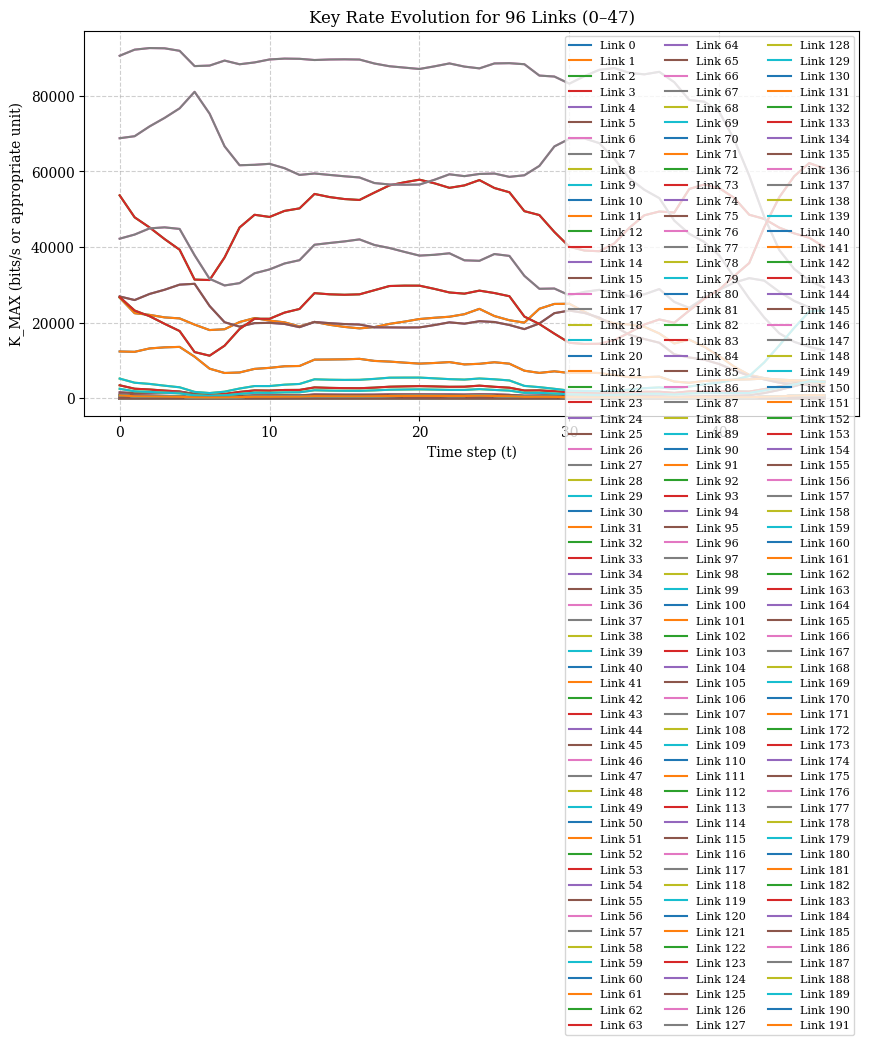

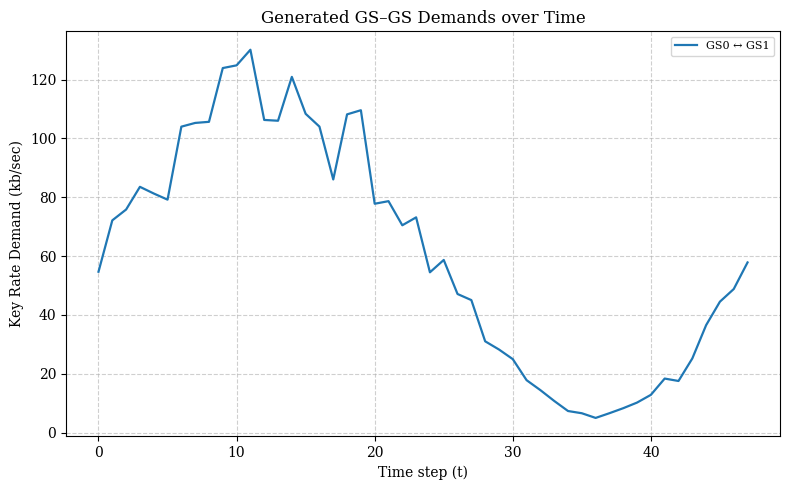

In [3]:
gnodes, hnodes, links, demands = init_setup_real_offline()

nodes = gnodes + hnodes

## Greedy

## RANDOM

## Rounding

In [4]:
NUM_DATA = 50

demand_list = [0.5 + 0.1*i for i in range(NUM_DATA)]
key_srv_grd = [0 for i in range(NUM_DATA)]
key_srv_rnd = [0 for i in range(NUM_DATA)]
key_srv_rlx = [0 for i in range(NUM_DATA)]

key_srv_grd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rnd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rlx_qkp = [0 for i in range(NUM_DATA)]

key_req = [0 for i in range(NUM_DATA)]

for idx, mean in enumerate(demand_list):
    demands = [generate_demands(gnodes, syst, mean_kbps=mean, amp=0.9, noise_std=0.1, pattern="sinusoidal")[0]]

    key_req[idx] = sum(d.K_REQ[t] * syst.THETA * 1e-3 for d in demands for t in syst.T)

    ########################################## Greedy #######################################################
    Z = [[[0 for t in syst.T] for d in demands] for l in links]

    ordr_dmnds = []
    for t in syst.T:
        ordr_dmnds.append(sorted(demands, key=lambda d: d.K_REQ[t], reverse=True))
    
    for t in syst.T:
        max_cnct_up  = [1] * len(nodes)
        max_cnct_dwn = [1] * len(nodes)
    
        for idx_d, d in enumerate(ordr_dmnds[t]):
            src, dst = d.n1, d.n2
    
            l1_sel = None
            l2_sel = None
            max_skr = 0
    
            for l_1 in links:
                for l_2 in links:
                    if l_1.n1 == src and l_2.n2 == dst and l_1.n2 == l_2.n1:
                        mid = l_1.n2
                        btln_skr = min(l_1.K_MAX[t], l_2.K_MAX[t])
    
                        if (
                            btln_skr > max_skr and
                            max_cnct_up[nodes.index(src)] > 0 and
                            max_cnct_dwn[nodes.index(dst)] > 0 and
                            max_cnct_up[nodes.index(mid)] > 0 and
                            max_cnct_dwn[nodes.index(mid)] > 0
                        ):
                            max_skr = btln_skr
                            l1_sel = l_1
                            l2_sel = l_2
    
            if l1_sel is not None:
                mid = l1_sel.n2
                max_cnct_up[nodes.index(src)] = 0
                max_cnct_dwn[nodes.index(dst)] = 0
                max_cnct_up[nodes.index(mid)] = 0
                max_cnct_dwn[nodes.index(mid)] = 0
    
                Z[links.index(l1_sel)][idx_d][t] = 1
                Z[links.index(l2_sel)][idx_d][t] = 1
                #print(f"({links.index(l1_sel)}, {idx_d}, {t})")
                #print(f"({links.index(l2_sel)}, {idx_d}, {t})")
    
    solution, key_srv_grd[idx]     = offline_lp(gnodes, hnodes, links, demands, 0, 2, Z)
    solution, key_srv_grd_qkp[idx] = offline_lp(gnodes, hnodes, links, demands, 1, 2, Z)

    key_srv_grd[idx]     *= 1e-3
    key_srv_grd_qkp[idx] *= 1e-3
    #########################################################################################################

    ########################################## Random #######################################################
    Z = [[[0 for t in syst.T] for d in demands] for l in links]

    for t in syst.T:
        max_cnct_up  = [1 for _ in nodes]
        max_cnct_dwn = [1 for _ in nodes]
    
        shuffled_demands = random.sample(demands, len(demands))
    
        for idx_d, d in enumerate(shuffled_demands):
            src, dst = d.n1, d.n2
    
            feasible_pairs = []
    
            for l1 in links:
                for l2 in links:
                    if (
                        l1.n1 == src and
                        l2.n2 == dst and
                        l1.n2 == l2.n1
                    ):
                        mid = l1.n2
                        if (
                            max_cnct_up[nodes.index(src)] > 0 and
                            max_cnct_dwn[nodes.index(dst)] > 0 and
                            max_cnct_up[nodes.index(mid)] > 0 and
                            max_cnct_dwn[nodes.index(mid)] > 0 and
                            l1.K_MAX[t] > 0 and
                            l2.K_MAX[t] > 0
                        ):
                            feasible_pairs.append((l1, l2))
    
            if feasible_pairs:
                l1_sel, l2_sel = random.choice(feasible_pairs)
                mid = l1_sel.n2
    
                Z[links.index(l1_sel)][demands.index(d)][t] = 1
                Z[links.index(l2_sel)][demands.index(d)][t] = 1
    
                max_cnct_up[nodes.index(src)] = 0
                max_cnct_dwn[nodes.index(dst)] = 0
                max_cnct_up[nodes.index(mid)] = 0
                max_cnct_dwn[nodes.index(mid)] = 0
    
    solution, key_srv_rnd[idx]     = offline_lp(gnodes, hnodes, links, demands, 0, 2, Z)
    solution, key_srv_rnd_qkp[idx] = offline_lp(gnodes, hnodes, links, demands, 1, 2, Z)

    key_srv_rnd[idx]     *= 1e-3
    key_srv_rnd_qkp[idx] *= 1e-3
    #########################################################################################################

    ########################################## Relaxed #######################################################
    #solution, key_srv_rlx[idx]     = offline_relaxed(gnodes, hnodes, links, demands, 0, 2)
    #solution, key_srv_rlx_qkp[idx] = offline_relaxed(gnodes, hnodes, links, demands, 1, 2)


=========== OPTIMAL SOLUTION FOUND ===========
k_req: 26443.151950250172, k_srv: 26299.800000000003

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 26443.151950250172, k_srv: 26440.2

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 26443.151950250172, k_srv: 26299.800000000003

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 26443.151950250172, k_srv: 26440.2

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 30943.510081718636, k_srv: 30609.0

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 30943.510081718636, k_srv: 30940.2

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 30943.510081718636, k_srv: 30609.0

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 30943.510081718636, k_srv: 30940.2

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 37176.31266632157, k_srv: 36462.600000000006

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 37176.31266632157, k_srv: 37179.0

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 37176.31266632

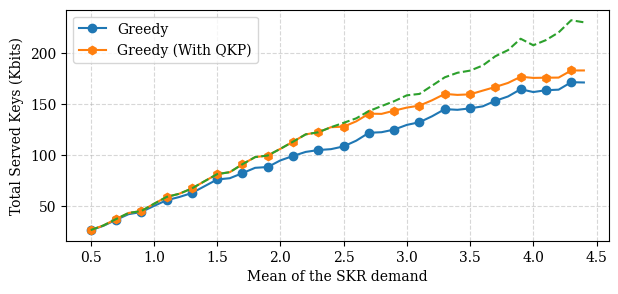

In [5]:
plt.figure(figsize=(7,3))
plt.plot(demand_list[0:40], key_srv_grd[0:40], label="Greedy", linestyle="-", marker="o", markevery=2)
#plt.plot(demand_list, key_srv_rnd, label="Random", linestyle="-", marker="^", markevery=2)
#plt.plot(demand_list, key_srv_rlx, label="Relaxed", linestyle="-", marker="x", markevery=2)

plt.plot(demand_list[0:40], key_srv_grd_qkp[0:40], label="Greedy (With QKP)", linestyle="-", marker="h", markevery=2)
#plt.plot(demand_list, key_srv_rnd_qkp, label="Random (With QKP)", linestyle="-", marker="*", markevery=2)
#plt.plot(demand_list, key_srv_rlx_qkp, label="Relaxed (With QKP)", linestyle="-", marker="s", markevery=2)

plt.plot(demand_list[0:40], key_req[0:40],  linestyle="--")

plt.xlabel("Mean of the SKR demand")
plt.ylabel("Total Served Keys (Kbits)")
#plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.savefig("offline_sinus.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
NUM_DATA = 50

demand_list = [0.5 + 0.1*i for i in range(NUM_DATA)]
key_srv_grd = [0 for i in range(NUM_DATA)]
key_srv_rnd = [0 for i in range(NUM_DATA)]
key_srv_rlx = [0 for i in range(NUM_DATA)]

key_srv_grd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rnd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rlx_qkp = [0 for i in range(NUM_DATA)]

key_req = [0 for i in range(NUM_DATA)]

for idx, mean in enumerate(demand_list):
    demands = []
    pairs = [(0,1)]#[(i, j) for i in range(len(gnodes)) for j in range(i+1, len(gnodes))]

    for (i, j) in pairs:
        gs1, gs2 = gnodes[i], gnodes[j]

        k_vals = []
        for t in syst.T:
            k_vals.append(mean)  # ensure positive rate

        demands.append(demand(k_vals, gs1, gs2))

    key_req[idx] = sum(d.K_REQ[t] * syst.THETA * 1e-3 for d in demands for t in syst.T)

    ########################################## Greedy #######################################################
    Z = [[[0 for t in syst.T] for d in demands] for l in links]

    ordr_dmnds = []
    for t in syst.T:
        ordr_dmnds.append(sorted(demands, key=lambda d: d.K_REQ[t], reverse=True))
    
    for t in syst.T:
        max_cnct_up  = [1] * len(nodes)
        max_cnct_dwn = [1] * len(nodes)
    
        for idx_d, d in enumerate(ordr_dmnds[t]):
            src, dst = d.n1, d.n2
    
            l1_sel = None
            l2_sel = None
            max_skr = 0
    
            for l_1 in links:
                for l_2 in links:
                    if l_1.n1 == src and l_2.n2 == dst and l_1.n2 == l_2.n1:
                        mid = l_1.n2
                        btln_skr = min(l_1.K_MAX[t], l_2.K_MAX[t])
    
                        if (
                            btln_skr > max_skr and
                            max_cnct_up[nodes.index(src)] > 0 and
                            max_cnct_dwn[nodes.index(dst)] > 0 and
                            max_cnct_up[nodes.index(mid)] > 0 and
                            max_cnct_dwn[nodes.index(mid)] > 0
                        ):
                            max_skr = btln_skr
                            l1_sel = l_1
                            l2_sel = l_2
    
            if l1_sel is not None:
                mid = l1_sel.n2
                max_cnct_up[nodes.index(src)] = 0
                max_cnct_dwn[nodes.index(dst)] = 0
                max_cnct_up[nodes.index(mid)] = 0
                max_cnct_dwn[nodes.index(mid)] = 0
    
                Z[links.index(l1_sel)][idx_d][t] = 1
                Z[links.index(l2_sel)][idx_d][t] = 1
                #print(f"({links.index(l1_sel)}, {idx_d}, {t})")
                #print(f"({links.index(l2_sel)}, {idx_d}, {t})")
    
    solution, key_srv_grd[idx]     = offline_lp(gnodes, hnodes, links, demands, 0, 2, Z)
    solution, key_srv_grd_qkp[idx] = offline_lp(gnodes, hnodes, links, demands, 1, 2, Z)

    key_srv_grd[idx]     *= 1e-3
    key_srv_grd_qkp[idx] *= 1e-3
    #########################################################################################################

    ########################################## Random #######################################################
    Z = [[[0 for t in syst.T] for d in demands] for l in links]

    for t in syst.T:
        max_cnct_up  = [1 for _ in nodes]
        max_cnct_dwn = [1 for _ in nodes]
    
        shuffled_demands = random.sample(demands, len(demands))
    
        for idx_d, d in enumerate(shuffled_demands):
            src, dst = d.n1, d.n2
    
            feasible_pairs = []
    
            for l1 in links:
                for l2 in links:
                    if (
                        l1.n1 == src and
                        l2.n2 == dst and
                        l1.n2 == l2.n1
                    ):
                        mid = l1.n2
                        if (
                            max_cnct_up[nodes.index(src)] > 0 and
                            max_cnct_dwn[nodes.index(dst)] > 0 and
                            max_cnct_up[nodes.index(mid)] > 0 and
                            max_cnct_dwn[nodes.index(mid)] > 0 and
                            l1.K_MAX[t] > 0 and
                            l2.K_MAX[t] > 0
                        ):
                            feasible_pairs.append((l1, l2))
    
            if feasible_pairs:
                l1_sel, l2_sel = random.choice(feasible_pairs)
                mid = l1_sel.n2
    
                Z[links.index(l1_sel)][demands.index(d)][t] = 1
                Z[links.index(l2_sel)][demands.index(d)][t] = 1
    
                max_cnct_up[nodes.index(src)] = 0
                max_cnct_dwn[nodes.index(dst)] = 0
                max_cnct_up[nodes.index(mid)] = 0
                max_cnct_dwn[nodes.index(mid)] = 0
    
    solution, key_srv_rnd[idx]     = offline_lp(gnodes, hnodes, links, demands, 0, 2, Z)
    solution, key_srv_rnd_qkp[idx] = offline_lp(gnodes, hnodes, links, demands, 1, 2, Z)

    key_srv_rnd[idx]     *= 1e-3
    key_srv_rnd_qkp[idx] *= 1e-3
    #########################################################################################################

    # Z = [[[0 for t in syst.T] for d in demands] for l in links]

    # for t in syst.T:
    #     max_up  = [1]*len(nodes)
    #     max_dwn = [1]*len(nodes)
    
    #     shuffled_links = random.sample(list(enumerate(links)), len(links))
    
    #     for idx_l, l in shuffled_links:
    #         u = l.n1
    #         v = l.n2
    
    #         if max_up[node_id[u]] and max_dwn[node_id[v]]:
    #             Z[idx_l][0][t] = 1   # demand index irrelevant, see note below
    
    #             max_up[node_id[u]] = 0
    #             max_dwn[node_id[v]] = 0

    ########################################## Relaxed #######################################################
    #solution, key_srv_rlx[idx]     = offline_relaxed(gnodes, hnodes, links, demands, 0, 2)
    #solution, key_srv_rlx_qkp[idx] = offline_relaxed(gnodes, hnodes, links, demands, 1, 2)


=========== OPTIMAL SOLUTION FOUND ===========
k_req: 43200.0, k_srv: 43113.600000000006

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 43200.0, k_srv: 43200.0

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 43200.0, k_srv: 43113.600000000006

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 43200.0, k_srv: 43200.0

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 51839.99999999999, k_srv: 51265.799999999996

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 51839.99999999999, k_srv: 51839.99999999999

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 51839.99999999999, k_srv: 51265.799999999996

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 51839.99999999999, k_srv: 51839.99999999999

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 60479.99999999999, k_srv: 58930.2

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 60479.99999999999, k_srv: 60479.99999999999

=========== OPTIMAL SOLUTION FOUND ===========
k_req: 60479.99999999999, k_

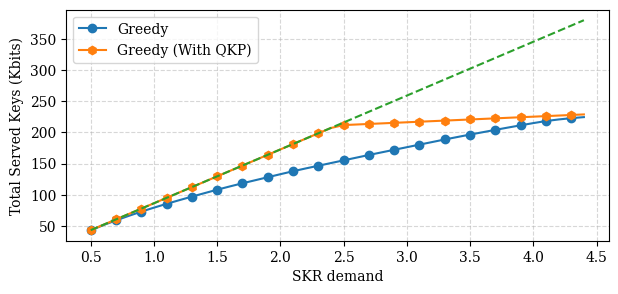

In [7]:
plt.figure(figsize=(7,3))
plt.plot(demand_list[0:40], key_srv_grd[0:40], label="Greedy", linestyle="-", marker="o", markevery=2)
#plt.plot(demand_list, key_srv_rnd, label="Random", linestyle="-", marker="^", markevery=2)
#plt.plot(demand_list, key_srv_rlx, label="Relaxed", linestyle="-", marker="x", markevery=2)

plt.plot(demand_list[0:40], key_srv_grd_qkp[0:40], label="Greedy (With QKP)", linestyle="-", marker="h", markevery=2)
#plt.plot(demand_list, key_srv_rnd_qkp, label="Random (With QKP)", linestyle="-", marker="*", markevery=2)
#plt.plot(demand_list, key_srv_rlx_qkp, label="Relaxed (With QKP)", linestyle="-", marker="s", markevery=2)

plt.plot(demand_list[0:40], key_req[0:40], linestyle="--")

plt.xlabel("SKR demand")
plt.ylabel("Total Served Keys (Kbits)")
#plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.savefig("offline_fixed.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# solution = offline(gnodes, hnodes, links, demands, 1, 0)